# Introduction

Welcome to the hands-on Colab notebook for TabPFN!

This install the online version of TabPFN using our web client. If you would like to access the offline version use: https://tinyurl.com/tabpfn-colab-local

**Installation**
* First, copy the notebook to be able to modify it.
* Then, run the cells in the installation block, this should
be good enough!

**API Registration**
* See the cell below to go through the registration process to use the pre-release TabPFN API for free.

---

> 🔵 **Hint** <br>
We recommend first enabling the **Table of Contents** with the `☰` icon in the top left and collapsing all sections by selecting all cells `Ctrl + Shift + A` and then pressing `Ctrl + ]`.

---

Thank you to [Lennart Purucker](https://github.com/LennartPurucker) for providing the original version of this notebook!

# Installation

The following cell installs a client that interacts with our pre-release API for the new version of TabPFN. This way, no GPU is required.

Restart your runtime and rerun the *cell*, if Colab asks for it.

In [1]:
# Install sklearn
!pip install scikit-learn==1.5.2

# Install TabPFN API Client
!pip install tabpfn-client

# TabPFN Extensions installs optional functionalities around the TabPFN model
# These include post-hoc ensembles, interpretability tools, and more
!git clone https://github.com/PriorLabs/tabpfn-extensions
!pip install -e tabpfn-extensions
!pip install tabpfn # TabPFN, currently required by tabpfn-extensions, but not basic usage


# Install Baselines
!pip install catboost xgboost

# Install example datasets
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 113.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 77.1 MB/s eta 0:00:00
Cloning into 'tabpfn-extensions'...
remote: Enumerating objects: 2089, done.
remote: Counting objects: 100% (288/288), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 2089 (delta 209), reused 175 (delta 175), pack-reused 1801 (from 2)
Receiving objects: 100% (2089/2089), 775.16 KiB | 22.15 MiB/s, done.
Resolving deltas: 100% (1273/1273), done.
Obtaining file:///content/tabpfn-extensions
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12

**Now Restart the Runtime**

# Necessary Imports for the Notebook

The examples in this notebook require the following imports.
Make sure to run this cell before any other cell.




In [2]:
pip install skfeature-chappers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 5.6 MB/s eta 0:00:00


In [3]:
pip install nanopq

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from nanopq import PQ  # Make sure you have nanopq installed: pip install nanopq
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from skfeature.function.information_theoretical_based import CMIM, JMI
import gc
import time
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from tabpfn import TabPFNClassifier

In [5]:
import scipy.spatial as ss
from scipy.special import digamma
from math import log
import numpy.random as nr
import numpy as np
import random
def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

In [6]:
import numpy as np
from math import log

def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

def fast_cmim(X, y, **kwargs):
    """
    This function implements the CMIM feature selection.
    Input
    -----
    X: {numpy array}, shape (n_samples, n_features)
        Input data, guaranteed to be a discrete numpy array
    y: {numpy array}, shape (n_samples,)
        guaranteed to be a numpy array
    kwargs: {dictionary}
        n_selected_features: {int}
            number of features to select
    Output
    ------
    F: {numpy array}, shape (n_features,)
        index of selected features, F[0] is the most important feature
    t1: {numpy array}, shape: (n_features,)
        minimal corresponding mutual information between selected features and response when
        conditionned on a previously selected feature
    Reference
    ---------
    Fleuret 2004 - Fast Binary Feature Selection with Conditional Mutual Information
    http://www.idiap.ch/~fleuret/papers/fleuret-jmlr2004.pdf
    """

    n_samples, n_features = X.shape
    is_n_selected_features_specified = False

    if 'n_selected_features' in kwargs.keys():
        n_selected_features = kwargs['n_selected_features']
        is_n_selected_features_specified = True
        F = np.nan * np.zeros(n_selected_features)
    else:
        F = np.nan * np.zeros(n_features)

    # t1
    t1 = np.zeros(n_features)

    # m is a counting indicator
    m = np.zeros(n_features) - 1

    for i in range(n_features):
        f = X[:, i]
        t1[i] = midd(f, y)


    for k in range(n_features):
        ### uncomment to keep track
        # counter = int(np.sum(~np.isnan(F)))
        # if counter%5 == 0 or counter <= 1:
        #     print("F contains %s features"%(counter))
        if k == 0:
            # select the feature whose mutual information is the largest
            idx = np.argmax(t1)
            F[0] = idx
            f_select = X[:, idx]

        if is_n_selected_features_specified:
            if np.sum(~np.isnan(F)) == n_selected_features:
                break

        sstar = -1000000 # start with really low value for best partial score sstar
        for i in range(n_features):

            if i not in F:

                while (t1[i] > sstar) and (m[i]<k-1) :
                    m[i] = m[i] + 1
                    t1[i] = min(t1[i], cmidd(X[:,i], # feature i
                                             y,  # target
                                             X[:, int(F[int(m[i])])] # conditionned on selected features
                                            )
                               )
                if t1[i] > sstar:
                    sstar = t1[i]
                    F[k+1] = i

    F = np.array(F[F>-100])
    F = F.astype(int)
    t1 = t1[F]
    return (F, t1)

# **Reading CSV file**

In [7]:
# Load data
data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
#data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-CIC-2020.csv")
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)

In [ ]:
data

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Class
0,0,0,0,0,0,0,0,0,0,1,...,1,1,1,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,1
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,0,1,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7126,0,0,0,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7128,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

In [ ]:
# record start time
start = time.time()
f, t = fast_cmim(X_train,y_train, n_selected_features = 100)
end = time.time()

# print the difference between start
# and end time in milli. secs
print("The time of execution of above program is :",
      (end-start), "sec")

The time of execution of above program is : 69.36624336242676 sec


In [ ]:
f

array([149,  86, 220, 228, 233, 152, 100, 163, 191, 229, 235, 237, 217,
       219, 218, 216, 236, 200, 225, 138, 182, 190, 223, 231, 221, 226,
        15,  62,   9, 214,  30,  74, 234, 137, 196, 119,  64,  76, 187,
       158, 232, 240, 230, 215,   5,   3,   4, 154,  19, 204,  25, 188,
       208,   7, 110, 238,  98, 141, 125,  47, 222,  59,  55, 239,  22,
       129,  44, 156, 209, 111, 205, 145,  54,  70,  80, 165, 155,  60,
       176, 150, 224, 212, 167,  63,  77, 112,   0,   6,  66, 107,  43,
       175,  78, 140, 114,  18,  72,  94, 171,  26])

In [8]:
f = [149,  86, 220, 228, 233, 152, 100, 163, 191, 229, 235, 237, 217,
       219, 218, 216, 236, 200, 225, 138, 182, 190, 223, 231, 221, 226,
        15,  62,   9, 214,  30,  74, 234, 137, 196, 119,  64,  76, 187,
       158, 232, 240, 230, 215,   5,   3,   4, 154,  19, 204,  25, 188,
       208,   7, 110, 238,  98, 141, 125,  47, 222,  59,  55, 239,  22,
       129,  44, 156, 209, 111, 205, 145,  54,  70,  80, 165, 155,  60,
       176, 150, 224, 212, 167,  63,  77, 112,   0,   6,  66, 107,  43,
       175,  78, 140, 114,  18,  72,  94, 171,  26]

In [9]:
f = np.array(f)
f

array([149,  86, 220, 228, 233, 152, 100, 163, 191, 229, 235, 237, 217,
       219, 218, 216, 236, 200, 225, 138, 182, 190, 223, 231, 221, 226,
        15,  62,   9, 214,  30,  74, 234, 137, 196, 119,  64,  76, 187,
       158, 232, 240, 230, 215,   5,   3,   4, 154,  19, 204,  25, 188,
       208,   7, 110, 238,  98, 141, 125,  47, 222,  59,  55, 239,  22,
       129,  44, 156, 209, 111, 205, 145,  54,  70,  80, 165, 155,  60,
       176, 150, 224, 212, 167,  63,  77, 112,   0,   6,  66, 107,  43,
       175,  78, 140, 114,  18,  72,  94, 171,  26])

In [10]:
selected_features_names=[]
for i in range(len(f)):
    selected_features_names.append(data.columns[f[i]])
selected_features_names

['RECEIVE_BOOT_COMPLETED',
 'GET_TASKS',
 'Ljava/net/URL;->openConnection',
 'Landroid/location/LocationManager;->getLastKgoodwarewnLocation',
 'Landroid/telephony/TelephonyManager;->getNetworkOperator',
 'RECEIVE_SMS',
 'KILL_BACKGROUND_PROCESSES',
 'SEND_SMS',
 'WAKE_LOCK',
 'Landroid/telephony/TelephonyManager;->getDeviceId',
 'Landroid/telephony/TelephonyManager;->getNetworkCountryIso',
 'Landroid/telephony/TelephonyManager;->getSimOperatorName',
 'Ljava/lang/System;->load',
 'Ljava/lang/System;->loadLibrary',
 'Ldalvik/system/DexClassLoader;->loadClass',
 'Ljava/lang/Runtime;->exec',
 'Landroid/telephony/TelephonyManager;->getSimOperator',
 'WRITE_EXTERNAL_STORAGE',
 'Landroid/media/AudioRecord;->startRecording',
 'READ_PHONE_STATE',
 'SYSTEM_ALERT_WINDOW',
 'VIBRATE',
 'Landroid/telephony/SmsManager;->sendMultipartTextMessage',
 'Landroid/content/pm/PackageManager;->getInstalledPackages',
 'Landroid/hardware/Camera;->open',
 'Landroid/telephony/TelephonyManager;->getCellLocation'

In [11]:
len(selected_features_names)

100

# find the highest accuracy with respect to different number of features

In [ ]:
from tabpfn import TabPFNClassifier

tab_pfn_={
    "acc":{"index":[],"val":[],},
    "per":{"index":[],"val":[],},
    "rec":{"index":[],"val":[],},
    "f1s":{"index":[],"val":[],},
    "auc":{"index":[],"val":[],},
}

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
for i in range(2,len(selected_features_names)+1,2):
    X = data[selected_features_names[:i]].values  # Features
    y = data.iloc[:, -1].values   # Binary labels (0 or 1)
    start = time.time()
    pq_pq = PQ(M=int(i/2), Ks=2)
    pq_pq.fit(X.astype(np.float32))
    codes_pq = pq_pq.encode(X.astype(np.float32))
    end = time.time()

    # print the difference between start
    # and end time in milli. secs
    print("The time of execution of above program is :",
          (end-start), "sec")
    X_train, X_test, y_train, y_test = train_test_split(codes_pq,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
    # Initialize a classifier
    clf = TabPFNClassifier()
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = clf.predict(X_test)
    end = time.time()
    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")
    tab_pfn_["acc"]['val'].append(accuracy_score(y_test, y_pred))
    tab_pfn_["acc"]['index'].append(i)
    tab_pfn_["per"]['val'].append(precision_score(y_test, y_pred))
    tab_pfn_["per"]['index'].append(i)
    tab_pfn_["rec"]['val'].append(recall_score(y_test, y_pred))
    tab_pfn_["rec"]['index'].append(i)
    tab_pfn_["f1s"]['val'].append(f1_score(y_test, y_pred))
    tab_pfn_["f1s"]['index'].append(i)

    y_prob = clf.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    tab_pfn_["auc"]['val'].append(auc(fpr, tpr))
    tab_pfn_["auc"]['index'].append(i)

M: 1, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 1
Encoding the subspace: 0 / 1
The time of execution of above program is : 0.008983135223388672 sec
The time of execution of training the tabpfn is : 205.61404752731323 sec
The time of execution of testing sample with the tabpfn is : 0.0005776761791983627 sec
M: 2, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 2
Training the subspace: 1 / 2
Encoding the subspace: 0 / 2
Encoding the subspace: 1 / 2
The time of execution of above program is : 0.01791834831237793 sec


/usr/local/lib/python3.11/dist-packages/nanopq/pq.py:123: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  self.codewords[m], _ = kmeans2(vecs_sub, self.Ks, iter=iter, minit=minit)


The time of execution of training the tabpfn is : 65.84476280212402 sec
The time of execution of testing sample with the tabpfn is : 0.0007352320709870541 sec
M: 3, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 3
Training the subspace: 1 / 3
Training the subspace: 2 / 3
Encoding the subspace: 0 / 3
Encoding the subspace: 1 / 3
Encoding the subspace: 2 / 3
The time of execution of above program is : 0.016005277633666992 sec


/usr/local/lib/python3.11/dist-packages/nanopq/pq.py:123: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  self.codewords[m], _ = kmeans2(vecs_sub, self.Ks, iter=iter, minit=minit)


The time of execution of training the tabpfn is : 46.82295322418213 sec
The time of execution of testing sample with the tabpfn is : 0.000806708155306994 sec
M: 4, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 4
Training the subspace: 1 / 4
Training the subspace: 2 / 4
Training the subspace: 3 / 4
Encoding the subspace: 0 / 4
Encoding the subspace: 1 / 4
Encoding the subspace: 2 / 4
Encoding the subspace: 3 / 4
The time of execution of above program is : 0.023575305938720703 sec


...

Training the subspace: 42 / 48
Training the subspace: 43 / 48
Training the subspace: 44 / 48
Training the subspace: 45 / 48
Training the subspace: 46 / 48
Training the subspace: 47 / 48
Encoding the subspace: 0 / 48
Encoding the subspace: 1 / 48
Encoding the subspace: 2 / 48
Encoding the subspace: 3 / 48
Encoding the subspace: 4 / 48
Encoding the subspace: 5 / 48
Encoding the subspace: 6 / 48
Encoding the subspace: 7 / 48
Encoding the subspace: 8 / 48
Encoding the subspace: 9 / 48
Encoding the subspace: 10 / 48
Encoding the subspace: 11 / 48
Encoding the subspace: 12 / 48
Encoding the subspace: 13 / 48
Encoding the subspace: 14 / 48
Encoding the subspace: 15 / 48
Encoding the subspace: 16 / 48
Encoding the subspace: 17 / 48
Encoding the subspace: 18 / 48
Encoding the subspace: 19 / 48
Encoding the subspace: 20 / 48
Encoding the subspace: 21 / 48
Encoding the subspace: 22 / 48
Encoding the subspace: 23 / 48
Encoding the subspace: 24 / 48
Encoding the subspace: 25 / 48
Encoding the subsp

/usr/local/lib/python3.11/dist-packages/nanopq/pq.py:123: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  self.codewords[m], _ = kmeans2(vecs_sub, self.Ks, iter=iter, minit=minit)


Training the subspace: 44 / 49
Training the subspace: 45 / 49
Training the subspace: 46 / 49
Training the subspace: 47 / 49
Training the subspace: 48 / 49
Encoding the subspace: 0 / 49
Encoding the subspace: 1 / 49
Encoding the subspace: 2 / 49
Encoding the subspace: 3 / 49
Encoding the subspace: 4 / 49
Encoding the subspace: 5 / 49
Encoding the subspace: 6 / 49
Encoding the subspace: 7 / 49
Encoding the subspace: 8 / 49
Encoding the subspace: 9 / 49
Encoding the subspace: 10 / 49
Encoding the subspace: 11 / 49
Encoding the subspace: 12 / 49
Encoding the subspace: 13 / 49
Encoding the subspace: 14 / 49
Encoding the subspace: 15 / 49
Encoding the subspace: 16 / 49
Encoding the subspace: 17 / 49
Encoding the subspace: 18 / 49
Encoding the subspace: 19 / 49
Encoding the subspace: 20 / 49
Encoding the subspace: 21 / 49
Encoding the subspace: 22 / 49
Encoding the subspace: 23 / 49
Encoding the subspace: 24 / 49
Encoding the subspace: 25 / 49
Encoding the subspace: 26 / 49
Encoding the subsp

/usr/local/lib/python3.11/dist-packages/nanopq/pq.py:123: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  self.codewords[m], _ = kmeans2(vecs_sub, self.Ks, iter=iter, minit=minit)


Training the subspace: 44 / 50
Training the subspace: 45 / 50
Training the subspace: 46 / 50
Training the subspace: 47 / 50
Training the subspace: 48 / 50
Training the subspace: 49 / 50
Encoding the subspace: 0 / 50
Encoding the subspace: 1 / 50
Encoding the subspace: 2 / 50
Encoding the subspace: 3 / 50
Encoding the subspace: 4 / 50
Encoding the subspace: 5 / 50
Encoding the subspace: 6 / 50
Encoding the subspace: 7 / 50
Encoding the subspace: 8 / 50
Encoding the subspace: 9 / 50
Encoding the subspace: 10 / 50
Encoding the subspace: 11 / 50
Encoding the subspace: 12 / 50
Encoding the subspace: 13 / 50
Encoding the subspace: 14 / 50
Encoding the subspace: 15 / 50
Encoding the subspace: 16 / 50
Encoding the subspace: 17 / 50
Encoding the subspace: 18 / 50
Encoding the subspace: 19 / 50
Encoding the subspace: 20 / 50
Encoding the subspace: 21 / 50
Encoding the subspace: 22 / 50
Encoding the subspace: 23 / 50
Encoding the subspace: 24 / 50
Encoding the subspace: 25 / 50
Encoding the subsp

In [ ]:
print("the highest accuracy where the number of features is: ", tab_pfn_["acc"]['index'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))])
print("the highest accuracy value is: ", tab_pfn_["acc"]['val'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))])
print("the highest AUC where the number of features is: ", tab_pfn_["auc"]['index'][tab_pfn_["auc"]['val'].index(max(tab_pfn_["auc"]['val']))])
print("the highest AUC value is: ", tab_pfn_["auc"]['val'][tab_pfn_["auc"]['val'].index(max(tab_pfn_["auc"]['val']))])
print("the highest precision where the number of features is: ", tab_pfn_["per"]['index'][tab_pfn_["per"]['val'].index(max(tab_pfn_['per']['val']))])
print("the highest precision value is: ", tab_pfn_["per"]['val'][tab_pfn_["per"]['val'].index(max(tab_pfn_['per']['val']))])
print("the highest recall where the number of features is: ", tab_pfn_["rec"]['index'][tab_pfn_["rec"]['val'].index(max(tab_pfn_["rec"]['val']))])
print("the highest recall value is: ", tab_pfn_["rec"]['val'][tab_pfn_["rec"]['val'].index(max(tab_pfn_["rec"]['val']))])
print("the highest f1_score where the number of features is: ", tab_pfn_["f1s"]['index'][tab_pfn_["f1s"]['val'].index(max(tab_pfn_["f1s"]['val']))])
print("the highest f1_score value is: ", tab_pfn_["f1s"]['val'][tab_pfn_["f1s"]['val'].index(max(tab_pfn_["f1s"]['val']))])

the highest accuracy where the number of features is:  66
the highest accuracy value is:  0.9922861150070126
the highest AUC where the number of features is:  74
the highest AUC value is:  0.9995937918010858
the highest precision where the number of features is:  66
the highest precision value is:  1.0
the highest recall where the number of features is:  52
the highest recall value is:  0.9860335195530726
the highest f1_score where the number of features is:  66
the highest f1_score value is:  0.9922589725545391


In [ ]:
tab_pfn_["auc"]['val'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))]

np.float64(0.9992554488944841)

In [ ]:
tab_pfn_['acc']['val'][32] #66 features

0.9922861150070126

In [ ]:
tab_pfn_['acc']['val'][36] #74 features

0.9922861150070126

In [ ]:
tab_pfn_['auc']['val'][32] #66 features

0.9992554488944841

In [ ]:
tab_pfn_['auc']['val'][36] #74 features

0.9995937918010858

In [ ]:
tab_pfn_['per']['val'][32] #66 features

1.0

In [ ]:
tab_pfn_['per']['val'][36] #74 features

1.0

In [ ]:
tab_pfn_['rec']['val'][32] #66 features

0.9846368715083799

In [ ]:
tab_pfn_['rec']['val'][36] #74 features

0.9846368715083799

In [ ]:
tab_pfn_['f1s']['val'][32] #66 features

0.9922589725545391

In [ ]:
tab_pfn_['f1s']['val'][36] #74 features

0.9922589725545391

In [ ]:
tab_pfn_

{'acc': {'index': [2,
   4,
   6,
   8,
   10,
   12,
   14,
   16,
   18,
   20,
   22,
   24,
   26,
   28,
   30,
   32,
   34,
   36,
   38,
   40,
   42,
   44,
   46,
   48,
   50,
   52,
   54,
   56,
   58,
   60,
   62,
   64,
   66,
   68,
   70,
   72,
   74,
   76,
   78,
   80,
   82,
   84,
   86,
   88,
   90,
   92,
   94,
   96,
   98,
   100],
  'val': [0.8513323983169705,
   0.8695652173913043,
   0.8786816269284713,
   0.879382889200561,
   0.8955119214586256,
   0.8955119214586256,
   0.9004207573632539,
   0.9018232819074333,
   0.9228611500701263,
   0.9663394109396914,
   0.967741935483871,
   0.9649368863955119,
   0.9719495091164095,
   0.9733520336605891,
   0.9803646563814866,
   0.9803646563814866,
   0.9803646563814866,
   0.9789621318373072,
   0.979663394109397,
   0.979663394109397,
   0.979663394109397,
   0.9831697054698457,
   0.9845722300140253,
   0.9845722300140253,
   0.985273492286115,
   0.9894810659186536,
   0.9894810659186536,
   0.991584852

In [ ]:
tab_pfn_['acc']['val']

[0.8513323983169705,
 0.8695652173913043,
 0.8786816269284713,
 0.879382889200561,
 0.8955119214586256,
 0.8955119214586256,
 0.9004207573632539,
 0.9018232819074333,
 0.9228611500701263,
 0.9663394109396914,
 0.967741935483871,
 0.9649368863955119,
 0.9719495091164095,
 0.9733520336605891,
 0.9803646563814866,
 0.9803646563814866,
 0.9803646563814866,
 0.9789621318373072,
 0.979663394109397,
 0.979663394109397,
 0.979663394109397,
 0.9831697054698457,
 0.9845722300140253,
 0.9845722300140253,
 0.985273492286115,
 0.9894810659186536,
 0.9894810659186536,
 0.9915848527349228,
 0.9915848527349228,
 0.9915848527349228,
 0.9915848527349228,
 0.9915848527349228,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9915848527349228,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9922861150070126,
 0.9915848527349228

In [ ]:
tab_pfn_["rec"]['val']

[np.float64(0.7653631284916201),
 np.float64(0.7430167597765364),
 np.float64(0.7667597765363129),
 np.float64(0.7681564245810056),
 np.float64(0.8240223463687151),
 np.float64(0.8240223463687151),
 np.float64(0.8268156424581006),
 np.float64(0.8296089385474861),
 np.float64(0.9273743016759777),
 np.float64(0.9678770949720671),
 np.float64(0.9804469273743017),
 np.float64(0.9804469273743017),
 np.float64(0.9832402234636871),
 np.float64(0.9804469273743017),
 np.float64(0.9832402234636871),
 np.float64(0.9832402234636871),
 np.float64(0.9832402234636871),
 np.float64(0.9804469273743017),
 np.float64(0.9832402234636871),
 np.float64(0.9832402234636871),
 np.float64(0.9818435754189944),
 np.float64(0.9818435754189944),
 np.float64(0.9846368715083799),
 np.float64(0.9846368715083799),
 np.float64(0.9846368715083799),
 np.float64(0.9860335195530726),
 np.float64(0.9860335195530726),
 np.float64(0.9846368715083799),
 np.float64(0.9846368715083799),
 np.float64(0.9846368715083799),
 np.float6

# find the average accuracy with respect to the best accuracy gained by 66 features

In [16]:
from tabpfn import TabPFNClassifier
import tracemalloc

tab_pfn_max={
    "acc":{"fold":[],"val":[],},
    "per":{"fold":[],"val":[],},
    "rec":{"fold":[],"val":[],},
    "f1s":{"fold":[],"val":[],},
    "auc":{"fold":[],"val":[],},
}
memory = {
    "current":[],
    "peak":[]
}

train_time=[]
test_time=[]

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
X = data[selected_features_names[:66]].values  # Features
#y = data.iloc[:, -1].values   # Binary labels (0 or 1)
start = time.time()
pq_pq = PQ(M=int(66/2), Ks=2)
pq_pq.fit(X.astype(np.float32))
codes_pq = pq_pq.encode(X.astype(np.float32))
end = time.time()

kf = KFold(n_splits=5, random_state=2, shuffle=True)
for q, (train_index, test_index) in enumerate(kf.split(codes_pq)):
    print(f"Fold {q+1}:")
    #print("The time of execution of Fold " ,q+1, " is :", (end-start), "sec")

    X_train = codes_pq[train_index]
    y_train = data["Class"].iloc[train_index].values
    X_test = codes_pq[test_index]
    y_test = data["Class"].iloc[test_index].values

    tracemalloc.start()

    clf = TabPFNClassifier()
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    train_time.append(end-start)
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = clf.predict(X_test)
    end = time.time()
    test_time.append((end-start)/len(X_test))

    c, p = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory["current"].append(c)
    memory['peak'].append(p)

    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")

    tab_pfn_max["acc"]['val'].append(accuracy_score(y_test, y_pred))
    tab_pfn_max["acc"]['fold'].append(q+1)
    tab_pfn_max["per"]['val'].append(precision_score(y_test, y_pred))
    tab_pfn_max["per"]['fold'].append(q+1)
    tab_pfn_max["rec"]['val'].append(recall_score(y_test, y_pred))
    tab_pfn_max["rec"]['fold'].append(q+1)
    tab_pfn_max["f1s"]['val'].append(f1_score(y_test, y_pred))
    tab_pfn_max["f1s"]['fold'].append(q+1)

    y_prob = clf.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    tab_pfn_max["auc"]['val'].append(auc(fpr, tpr))
    tab_pfn_max["auc"]['fold'].append(q+1)


M: 33, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 33
Training the subspace: 1 / 33
Training the subspace: 2 / 33
Training the subspace: 3 / 33
Training the subspace: 4 / 33
Training the subspace: 5 / 33
Training the subspace: 6 / 33
Training the subspace: 7 / 33
Training the subspace: 8 / 33
Training the subspace: 9 / 33
Training the subspace: 10 / 33
Training the subspace: 11 / 33
Training the subspace: 12 / 33
Training the subspace: 13 / 33
Training the subspace: 14 / 33
Training the subspace: 15 / 33
Training the subspace: 16 / 33
Training the subspace: 17 / 33
Training the subspace: 18 / 33
Training the subspace: 19 / 33
Training the subspace: 20 / 33
Training the subspace: 21 / 33
Training the subspace: 22 / 33
Training the subspace: 23 / 33
Training the subspace: 24 / 33
Training the subspace: 25 / 33
Training the subspace: 26 / 33
Training the subspace: 27 / 33
Training the subspace: 28 / 33
Training the subspace: 29 / 33

/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


The time of execution of training the tabpfn is : 32.298407316207886 sec
The time of execution of testing sample with the tabpfn is : 0.004125996191070257 sec
Fold 2:
The time of execution of training the tabpfn is : 33.900641679763794 sec
The time of execution of testing sample with the tabpfn is : 0.004027602548853378 sec
Fold 3:
The time of execution of training the tabpfn is : 35.21349501609802 sec
The time of execution of testing sample with the tabpfn is : 0.004047920626978721 sec
Fold 4:
The time of execution of training the tabpfn is : 33.84500551223755 sec
The time of execution of testing sample with the tabpfn is : 0.003982925649110599 sec
Fold 5:
The time of execution of training the tabpfn is : 33.256497383117676 sec
The time of execution of testing sample with the tabpfn is : 0.004069885231167872 sec


In [17]:
tab_pfn_max

{'acc': {'fold': [1, 2, 3, 4, 5],
  'val': [0.9922861150070126,
   0.9950911640953717,
   0.9887798036465638,
   0.9915848527349228,
   0.9936886395511921]},
 'per': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(1.0),
   np.float64(0.9945130315500685),
   np.float64(0.9914893617021276),
   np.float64(0.998587570621469),
   np.float64(1.0)]},
 'rec': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9846368715083799),
   np.float64(0.9958791208791209),
   np.float64(0.9858956276445698),
   np.float64(0.9846796657381616),
   np.float64(0.9870317002881844)]},
 'f1s': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9922589725545391),
   np.float64(0.9951956074124915),
   np.float64(0.9886845827439887),
   np.float64(0.9915848527349228),
   np.float64(0.9934735315445975)]},
 'auc': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9993046266425367),
   np.float64(0.9996920164362858),
   np.float64(0.9993685490200707),
   np.float64(0.9982354468627543),
   np.float64(0.9995068975291728)]}}

In [18]:
print(f"Current memory usage: {np.average(memory['current']) / 1024 / 1024:.1f} MB")
print(f"Peak usage: {np.average(memory['peak']) / 1024 / 1024:.1f} MB")

Current memory usage: 8.1 MB
Peak usage: 15.2 MB


In [19]:
print("The time of execution of training the tabpfn is :",
          np.average(train_time), "sec")
print("The time of execution of testing the tabpfn is :",
          np.average(test_time), "sec")

The time of execution of training the tabpfn is : 33.70280938148498 sec
The time of execution of testing the tabpfn is : 0.004050866049436165 sec


In [3]:
np.average(tab_pfn_max["acc"]["val"])

0.9922861150070126

In [4]:
np.average(tab_pfn_max["auc"]["val"])

0.9992215072981642

In [5]:
np.average(tab_pfn_max["per"]["val"])

0.996917992774733

In [6]:
np.average(tab_pfn_max["rec"]["val"])

0.9876245972116834

In [7]:
np.average(tab_pfn_max["f1s"]["val"])

0.9922395093981079

In [ ]:
accuracy_tabPFN = pd.DataFrame(tab_pfn_['acc']['val'], index=tab_pfn_['acc']['index'])
Precision_tabPFN = pd.DataFrame(tab_pfn_['per']['val'], index=tab_pfn_['per']['index'])
Recall_tabPFN = pd.DataFrame(tab_pfn_['rec']['val'], index=tab_pfn_['rec']['index'])
f1Score_tabPFN = pd.DataFrame(tab_pfn_['f1s']['val'], index=tab_pfn_['f1s']['index'])
auc_tabPFN = pd.DataFrame(tab_pfn_['auc']['val'], index=tab_pfn_['auc']['index'])

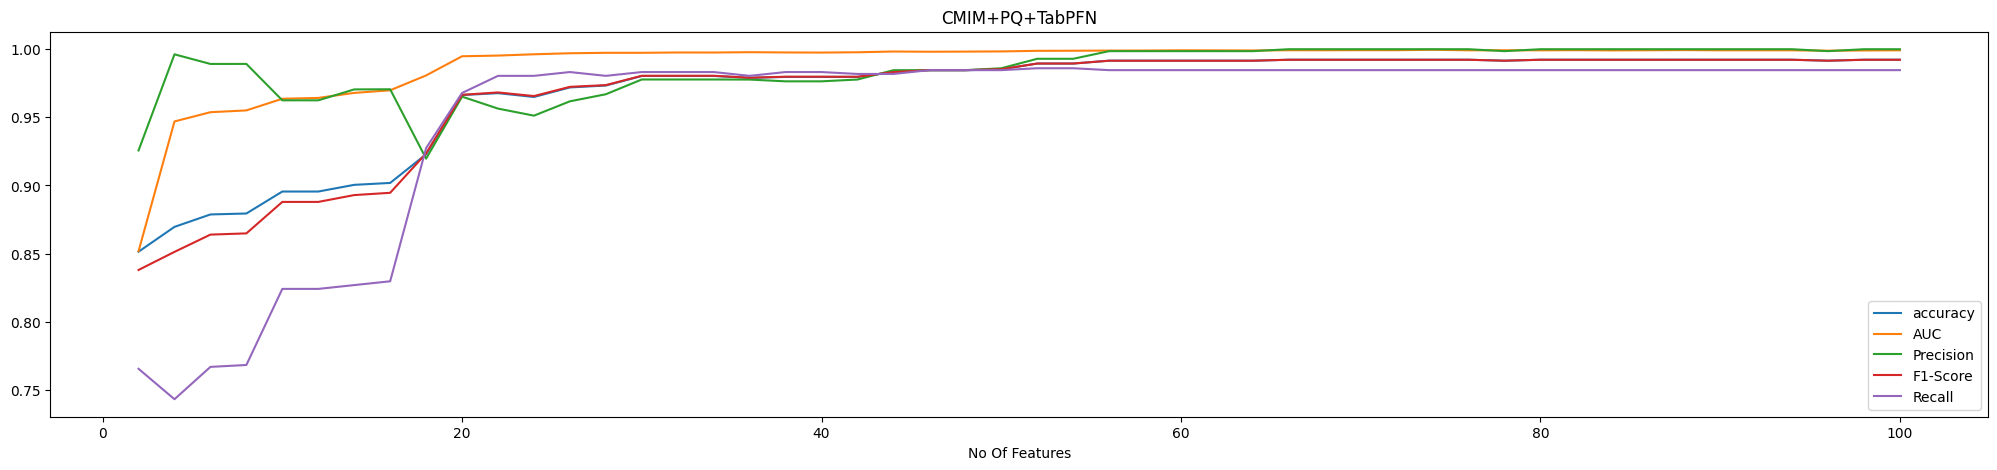

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_tabPFN, label="accuracy")
plt.plot(auc_tabPFN, label="AUC")
plt.plot(Precision_tabPFN, label="Precision")
plt.plot(f1Score_tabPFN, label="F1-Score")
plt.plot(Recall_tabPFN , label="Recall")

plt.title("CMIM+PQ+TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("")
plt.legend()
plt.show()

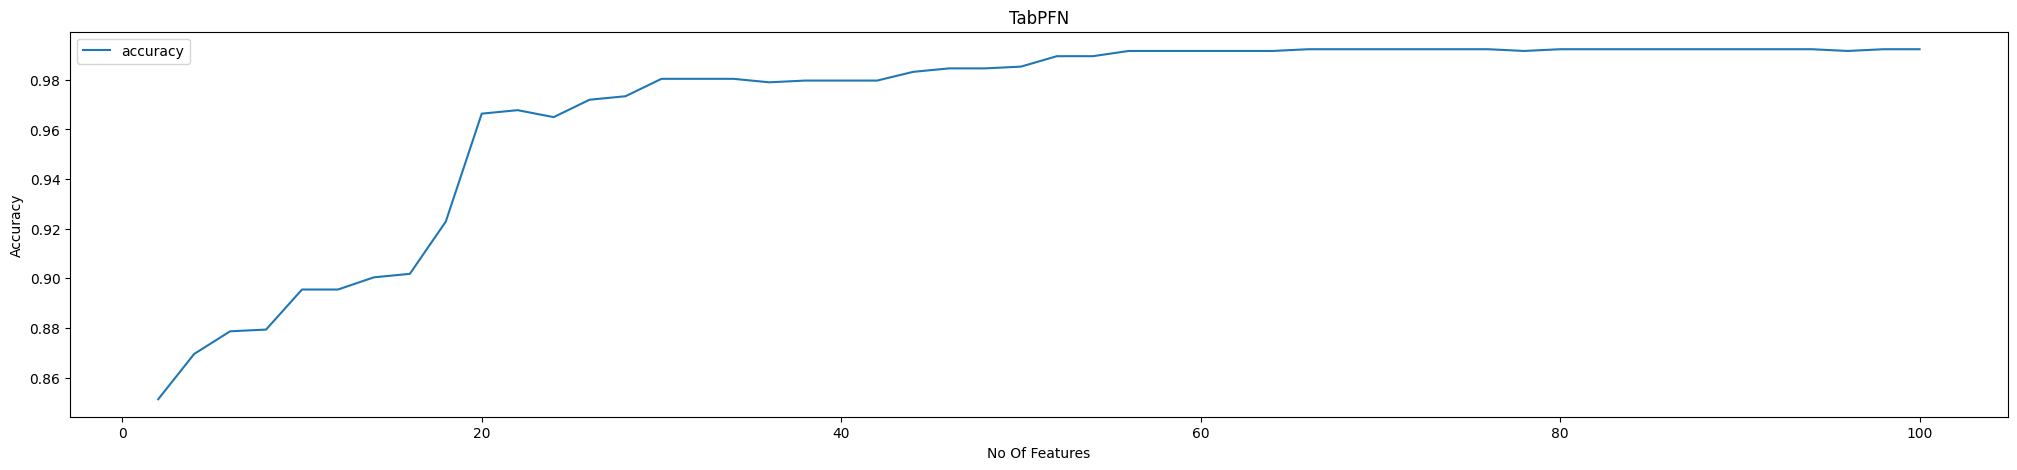

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_tabPFN, label="accuracy")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

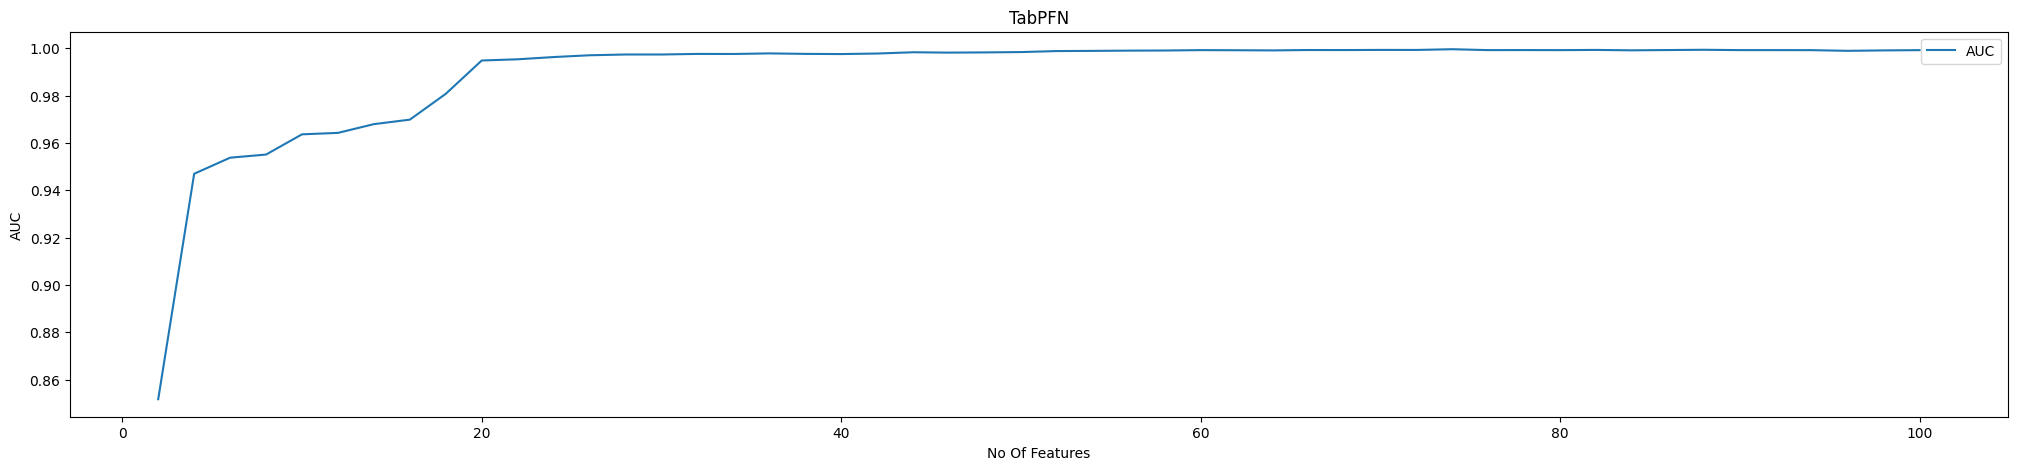

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(auc_tabPFN, label="AUC")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("AUC")
plt.legend()
plt.show()

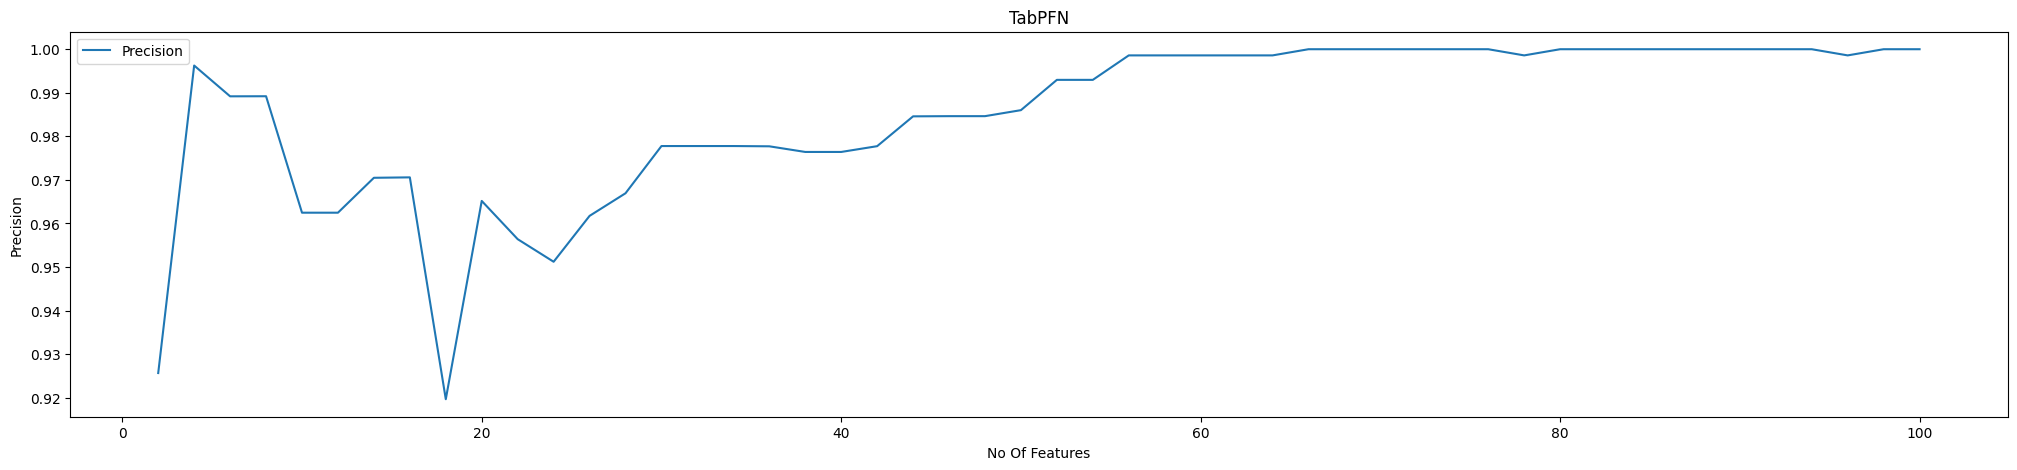

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(Precision_tabPFN, label="Precision")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Precision")
plt.legend()
plt.show()

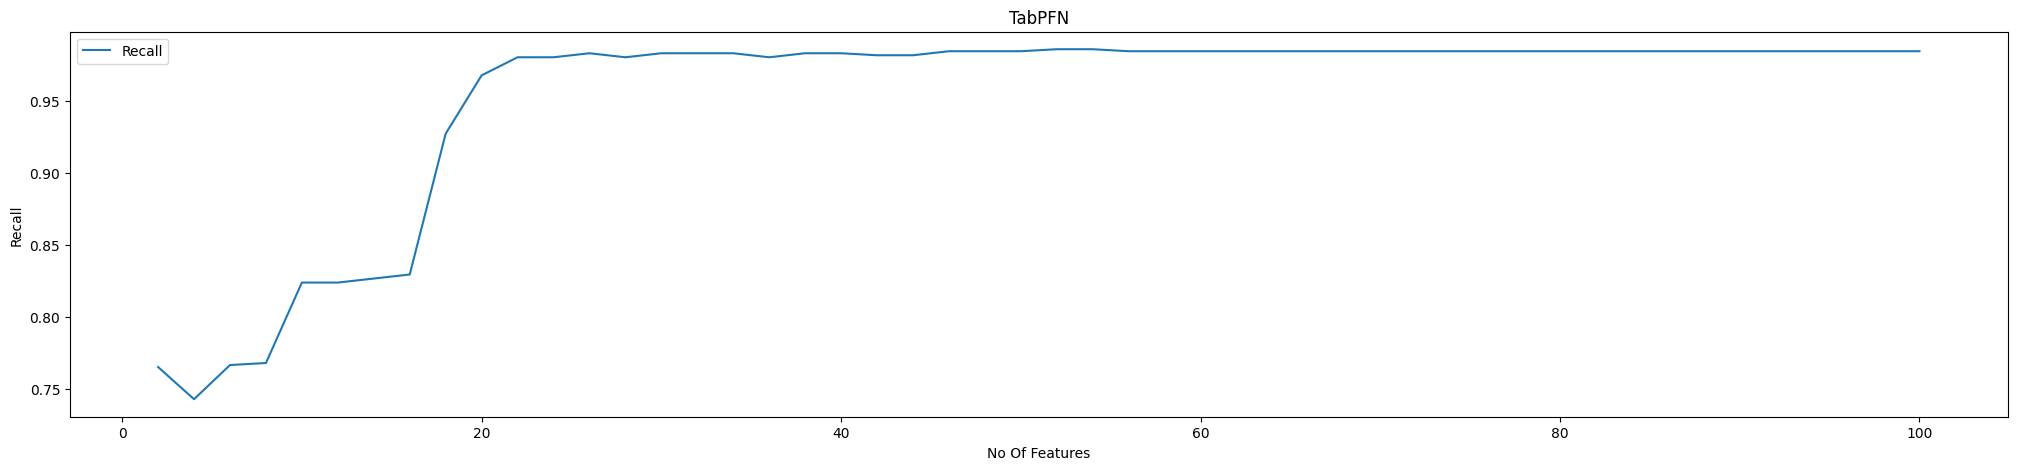

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(Recall_tabPFN , label="Recall")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Recall")
plt.legend()
plt.show()

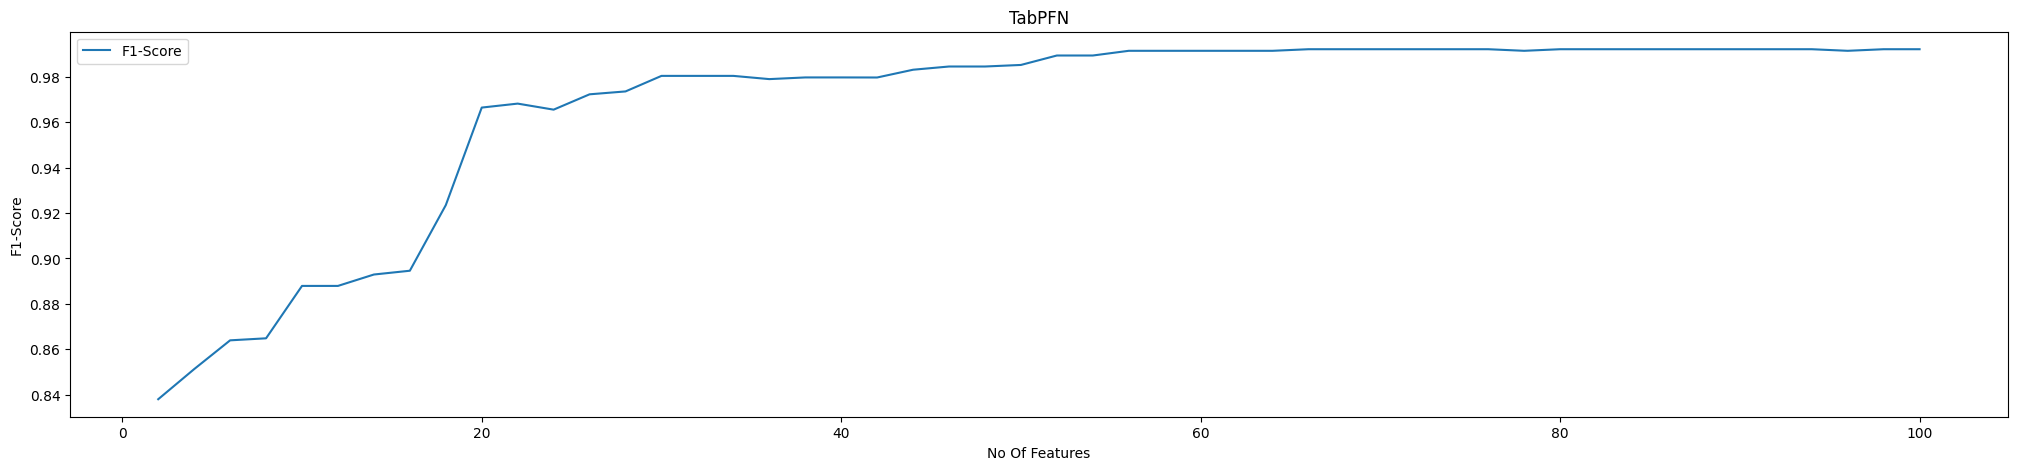

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(f1Score_tabPFN, label="F1-Score")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("F1-Score")
plt.legend()
plt.show()

# test the tabpfn with the total 100 **features**

In [ ]:
from tabpfn import TabPFNClassifier
data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
X = data[selected_features_names].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(codes_pq,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
# Initialize a classifier
clf = TabPFNClassifier()
start = time.time()
clf.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the tabpfn is :", (end-start), "sec")
# Predict labels
start = time.time()
y_pred = clf.predict(X_test)
end = time.time()
print("The time of execution of testing sample with the tabpfn is :", ((end-start)/len(X_test)), "sec")
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
y_prob = clf.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
print("AUC: ", auc(fpr, tpr))

The time of execution of training the tabpfn is : 8.224750280380249 sec
The time of execution of testing sample with the tabpfn is : 0.004008741733235364 sec
Accuracy_score:  0.9922861150070126
Precision_score:  1.0
Recall_score  0.9846368715083799
F1_score:  0.9922589725545391
AUC:  0.9992554488944841


In [ ]:
#SVM
X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)  # `probability=True` for AUC calculation

start = time.time()
svm_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the SVM is :",
          (end-start), "sec")

start = time.time()
y_pred = svm_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the SVM is :",
          ((end-start)/len(X_test)), "sec")

y_prob = svm_model.predict_proba(X_test)[:, 1]  # Get probability scores for ROC curve

# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the SVM is : 1.9641799926757812 sec
The time of execution of testing a sample of the SVM is : 0.00016676276128054667 sec
Accuracy_score:  0.9929873772791024
Precision_score:  1.0
Recall_score  0.9860335195530726
F1_score:  0.9929676511954993
AUC:  0.9979669918955072


In [ ]:
#Random forest
X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
rf_model = RandomForestClassifier(n_estimators=100, random_state=2)
start = time.time()
rf_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the RandomForest is :", (end-start), "sec")


# Make predictions on the test set
start = time.time()
y_pred = rf_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the RandomForest is :", ((end-start)/len(X_test)), "sec")

# Get probability estimates for the positive class (needed for ROC curve)
y_prob = rf_model.predict_proba(X_test)[:, 1]
# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the RandomForest is : 0.5930635929107666 sec
The time of execution of testing a sample of the RandomForest is : 1.7891759457795516e-05 sec
Accuracy_score:  0.9936886395511921
Precision_score:  1.0
Recall_score  0.9874301675977654
F1_score:  0.9936753338018272
AUC:  0.9994737980958376


In [ ]:
#Decision Tree
X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
dt_model = DecisionTreeClassifier()
start = time.time()
dt_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the DecisionTree is :", (end-start), "sec")

# Make predictions on the test set
start = time.time()
y_pred = dt_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the DecisionTree is :", ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = dt_model.predict_proba(X_test)[:, 1]

# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the DecisionTree is : 0.03497600555419922 sec
The time of execution of testing a sample of the DecisionTree is : 7.364893695248127e-07 sec
Accuracy_score:  0.9929873772791024
Precision_score:  0.998587570621469
Recall_score  0.9874301675977654
F1_score:  0.9929775280898876
AUC:  0.9983141867967582


In [ ]:
#Logistic Regression

X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
lr_model = LogisticRegression(random_state=2, solver='liblinear')
start = time.time()
lr_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the LogisticRegression is :", (end-start), "sec")

# Make predictions on the test set
start = time.time()
y_pred = lr_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the LogisticRegression is :", ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = lr_model.predict_proba(X_test)[:, 1]


# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the LogisticRegression is : 0.03131508827209473 sec
The time of execution of testing a sample of the LogisticRegression is : 7.339814602074751e-07 sec
Accuracy_score:  0.9866760168302945
Precision_score:  0.9943262411347518
Recall_score  0.979050279329609
F1_score:  0.9866291344123856
AUC:  0.9989780863954678


In [ ]:
#KNN

X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

knn = KNeighborsClassifier(n_neighbors=5)
start = time.time()
knn.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the KNeighbors is :", (end-start), "sec")

# Make predictions on the test set
start = time.time()
y_pred = knn.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the LogisticRegression is :", ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = knn.predict_proba(X_test)[:, 1]



# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the KNeighbors is : 0.000720977783203125 sec
The time of execution of testing a sample of the LogisticRegression is : 0.0002069357902772965 sec
Accuracy_score:  0.9901823281907434
Precision_score:  0.9957627118644068
Recall_score  0.9846368715083799
F1_score:  0.9901685393258427
AUC:  0.997061137776379


In [ ]:
#Naive Bayes

X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

nb_model = GaussianNB()
start = time.time()
nb_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the GaussianNB is :", (end-start), "sec")


# Make predictions on the test set
start = time.time()
y_pred = nb_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the GaussianNB is :", ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = nb_model.predict_proba(X_test)[:, 1]



# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the GaussianNB is : 0.017922401428222656 sec
The time of execution of testing a sample of the GaussianNB is : 2.25160098510571e-06 sec
Accuracy_score:  0.5315568022440392
Precision_score:  0.9285714285714286
Recall_score  0.07262569832402235
F1_score:  0.13471502590673576
AUC:  0.9766582736643326


In [ ]:
#Gradient Boosting

X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=2)
start = time.time()
gb_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the GradientBoosting is :",
          (end-start), "sec")

# Make predictions on the test set
start = time.time()
y_pred = gb_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the GradientBoosting is :",
          ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = gb_model.predict_proba(X_test)[:, 1]


# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the GradientBoosting is : 2.1560282707214355 sec
The time of execution of testing a sample of the GradientBoosting is : 3.820214666123142e-06 sec
Accuracy_score:  0.9873772791023843
Precision_score:  0.9957386363636364
Recall_score  0.979050279329609
F1_score:  0.9873239436619718
AUC:  0.9988875993390511


In [ ]:
#XGBoost

X = data.drop("Class", axis=1).values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=2)
start = time.time()
xgb_model.fit(X_train, y_train)
end = time.time()
print("The time of execution of training the GradientBoosting is :",
          (end-start), "sec")


# Make predictions on the test set
start = time.time()
y_pred = xgb_model.predict(X_test)
end = time.time()
print("The time of execution of testing a sample of the GradientBoosting is :",
          ((end-start)/len(X_test)), "sec")
# Get probability estimates for the positive class (needed for ROC curve)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Calculate performance metrics
print("Accuracy_score: ", accuracy_score(y_test, y_pred))
print("Precision_score: ", precision_score(y_test, y_pred))
print("Recall_score ",recall_score(y_test, y_pred))
print("F1_score: ",f1_score(y_test, y_pred))
fpr, tpr, _ = roc_curve(y_test, y_prob)
print("AUC: ", auc(fpr, tpr))

The time of execution of training the GradientBoosting is : 0.3192477226257324 sec
The time of execution of testing a sample of the GradientBoosting is : 5.018995319810522e-06 sec
Accuracy_score:  0.9936886395511921
Precision_score:  1.0
Recall_score  0.9874301675977654
F1_score:  0.9936753338018272
AUC:  0.9996783775277363
